In [6]:
import baltic as bt
import re

In [7]:
def prep(treesort_path, output_filename):
        
    with open(treesort_path, 'r') as file:
        modified = file.read()
        
    # removing commas between segments
    modified = re.sub(r'&rea="([^"]+)"', lambda match: f'&rea="{match.group(1).replace(",", "-")}"', modified)
    
    # removing quotation marks around node names
    modified = re.sub(r"'(TS_NODE_\d+)'", r'\1', modified)
    
    # replacing ? with _ so baltic can read it in
    modified = modified.replace('?', '_')
    
    with open(output_filename, "w") as output_file:
        output_file.write(modified.strip())
        
    mytree = bt.loadNewick(output_filename, absoluteTime= False)
    
    return(mytree)

In [8]:
mytree = prep("summary.nwk", "baltic_summary.nwk")

In [9]:
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as ticker

def plot_rea(mytree):
    
    plt.rcParams["font.family"] = "Arial"

    fig, ax = plt.subplots(figsize=(15, 10))

    x_attr = lambda k: k.x
    
    def color_by(k):
        return "#f4a261" if k.traits["is_reassorted"] else "grey"


    mytree.plotTree(ax, x_attr=x_attr, colour=color_by, width=3)
    
    def reassorted_func(k):
        if k.traits["is_reassorted"]:
            return 100
        else:
            return 0
        
    def nonreassorted_func(k):
        if not k.traits["is_reassorted"]:
            return 100
        else:
            return 0
    
    mytree.plotPoints(ax,
                x_attr=x_attr,
                size=lambda k: nonreassorted_func(k),
                colour=color_by,
                zorder=4,
                marker='o'
                    )
    
    mytree.plotPoints(ax,
                x_attr=x_attr,
                size=lambda k: reassorted_func(k),
                colour=color_by,
                zorder=5,
                marker='o'
                    )
    
    legend_elements = [
        Patch(facecolor='#f4a261', edgecolor='#f4a261', label='Reassorted'),
        Patch(facecolor='grey', edgecolor='grey', label='Non-reassorted')
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=25, title_fontsize=30)


    ax.set_yticks([])
    ax.set_yticklabels([])
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
    ax.tick_params(axis='x',labelsize=30,size=15, width=2,color='grey')
    ax.set_xlabel("Divergence", fontsize=25)
    fig.tight_layout()
     
    plt.savefig("rea.pdf")
    plt.show()

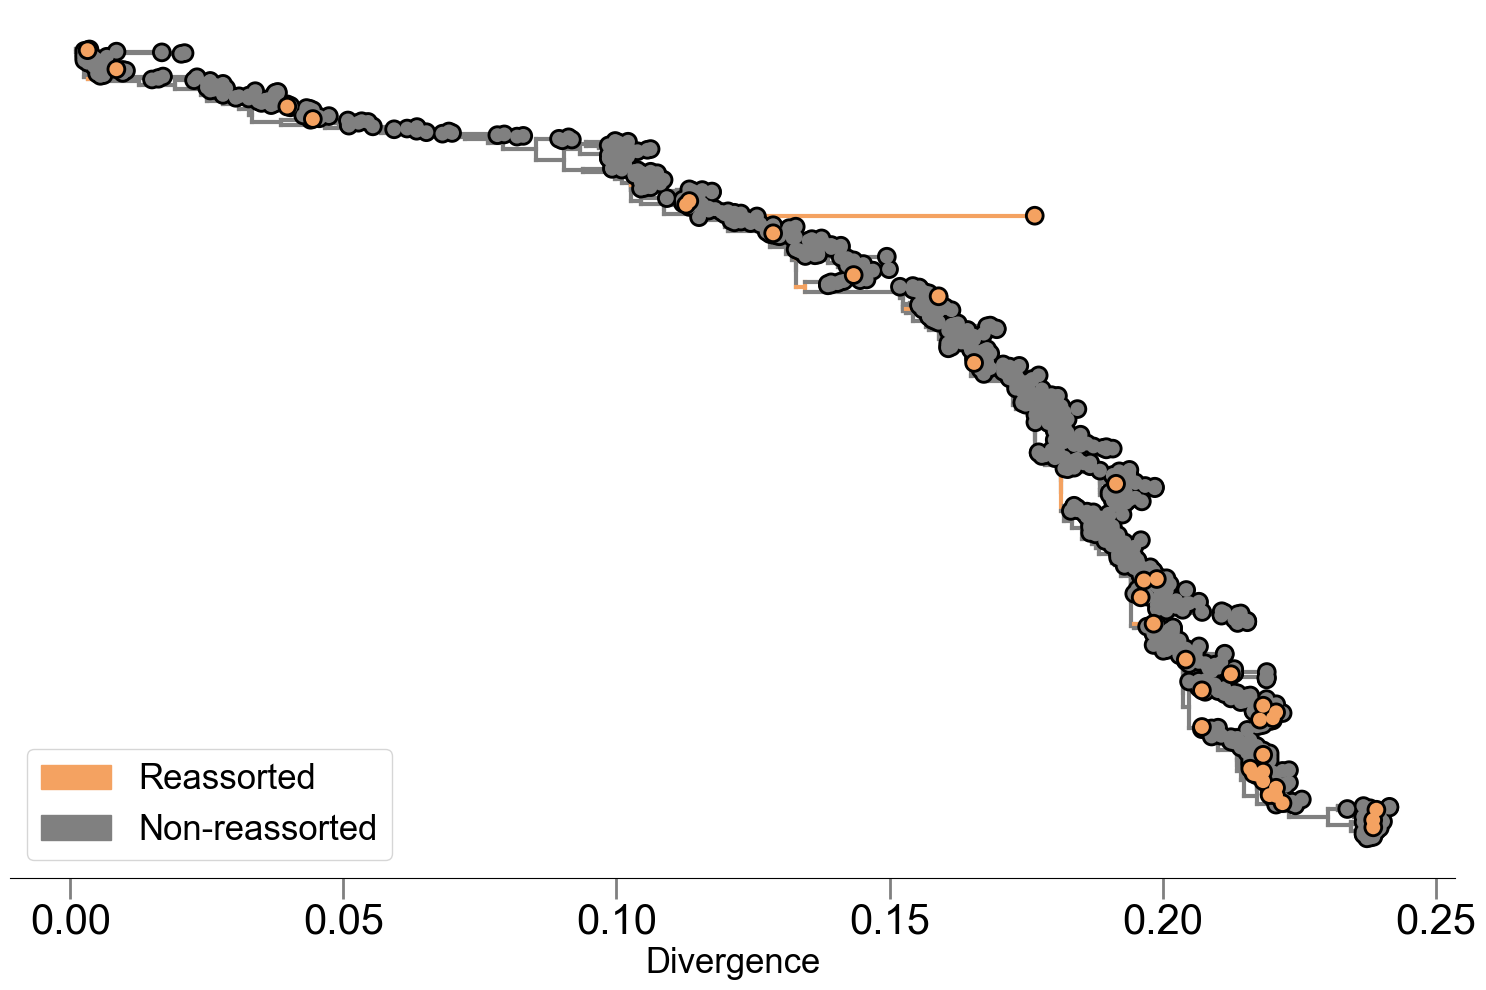

In [10]:
plot_rea(mytree)